In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
def write_natural_member(var, scen, number, daily_ANT, scaling_factor):

    mem_ds = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/daily/inputs/FWI_inputs_"+scen+"_run"+number+"_1959-2018.nc")
    mem_da = mem_ds[var]
    
    nat_mem = mem_da - scaling_factor * daily_ANT

    nat_mem.to_netcdf('/nesi/nobackup/niwa00015/queenle/CAM5/daily/naturalized/'+var+'_'+scen+'_run'+number+'_1959-2018.nc')

In [16]:
'''
NATURALIZE CAM5 TEMP AND RH
'''

ALL_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_All_ensMean.nc')
NAT_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_Nat_ensMean.nc')
ex_mem_da = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/daily/inputs/FWI_inputs_All_run001_1959-2018.nc")['tasmax']
beta_est_df = pd.read_csv('/home/queenle/fire_attribution/result_files/cam5_beta_est_trunc_30_1959_2014.csv')
beta_est_df.set_index('type',inplace=True)

titles = {'tasmax':'temp','rh':'rel. humidity'}

var = input('tasmax or rh: ')
print('naturalizing cam5 ' + var)

ALL_da = ALL_ds[var]
NAT_da = NAT_ds[var]

ANT_da = ALL_da - NAT_da
daily_ANT = ANT_da.reindex_like(ex_mem_da, method="bfill")

scaling_factor = beta_est_df.loc['best_ant'][titles[var]]

runs = [i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)]
for scen in ['All']:
    for ens_mem in runs:
        
        print(ens_mem)

        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        write_natural_member(var, scen, number, daily_ANT, scaling_factor)



naturalizing cam5 tasmax
1


1


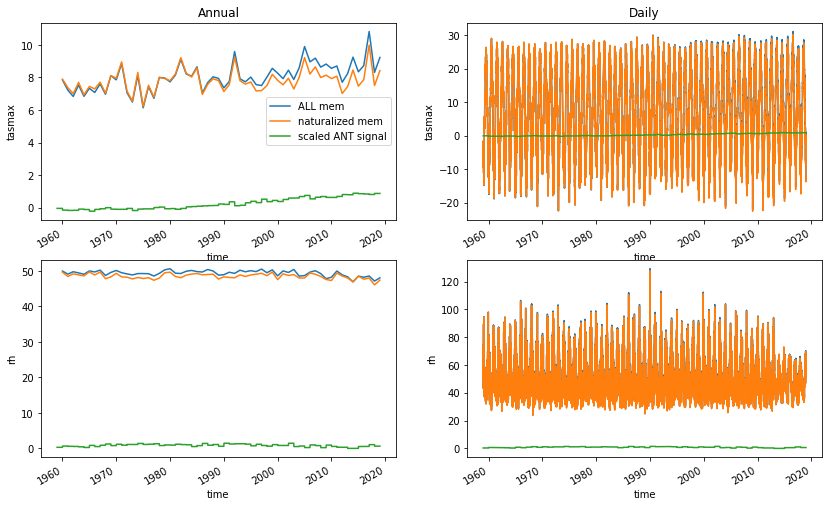

2


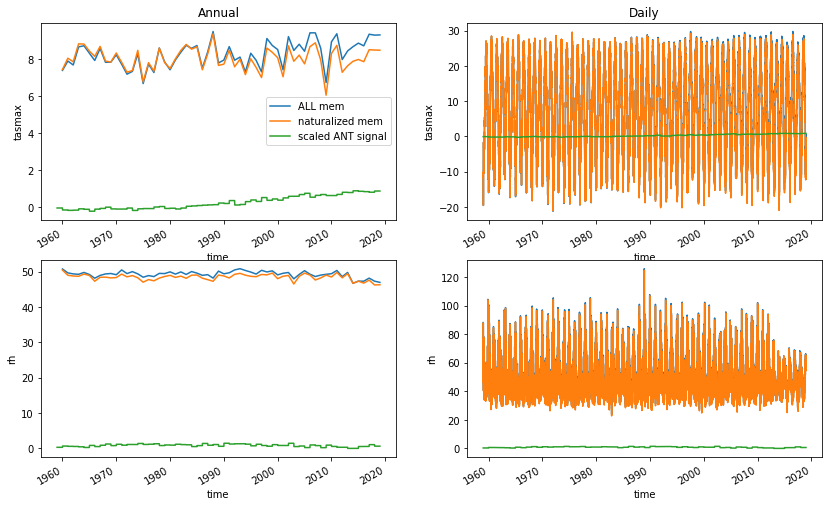

3


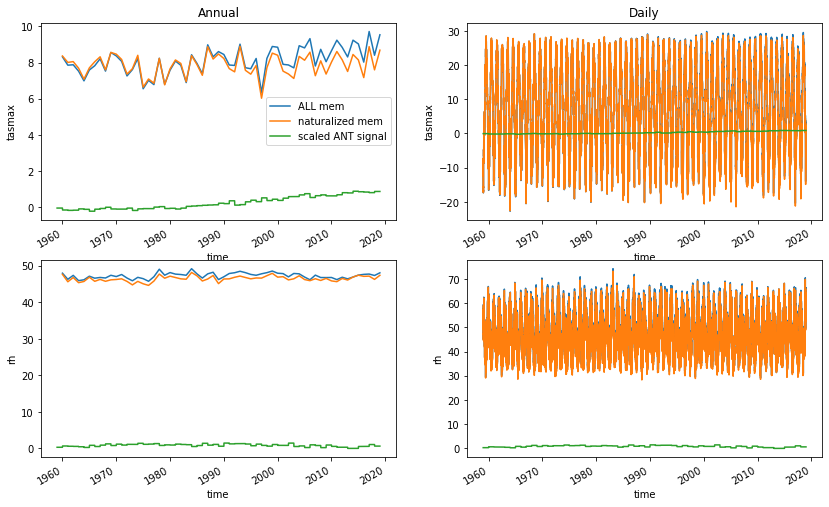

4


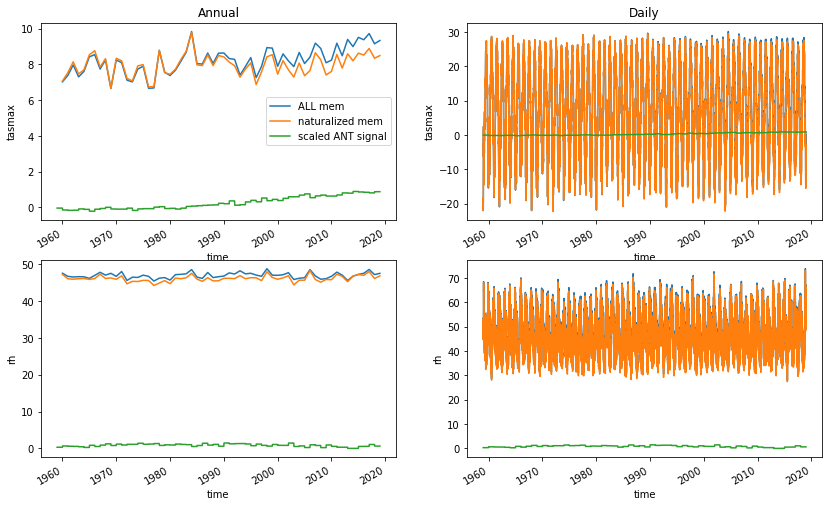

5


KeyboardInterrupt: 

In [4]:
'''
PLOTTING NATURALIZED TA AND RH
'''

ALL_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_All_ensMean.nc')
NAT_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_Nat_ensMean.nc')
ex_mem_da = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/daily/inputs/FWI_inputs_All_run001_1959-2018.nc")['tasmax']
beta_est_df = pd.read_csv('/home/queenle/fire_attribution/result_files/cam5_beta_est_trunc_30_1959_2014.csv')
beta_est_df.set_index('type',inplace=True)

titles = {'tasmax':'temp','rh':'rel. humidity'}

tasmax_ANT_da = ALL_ds['tasmax'] - NAT_ds['tasmax']
tasmax_daily_ANT = tasmax_ANT_da.reindex_like(ex_mem_da, method="bfill")
rh_ANT_da = ALL_ds['rh'] - NAT_ds['rh']
rh_daily_ANT = rh_ANT_da.reindex_like(ex_mem_da, method="bfill")
ANT_dict = {'tasmax':tasmax_daily_ANT,'rh':rh_daily_ANT}

runs = [i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)]
scen='All'
for ens_mem in runs:

    print(ens_mem)

    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
        
    mem_ds = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/daily/inputs/FWI_inputs_"+scen+"_run"+number+"_1959-2018.nc")
    fig,axs = plt.subplots(2,2,figsize=(14,8))
    for i,var in enumerate(['tasmax','rh']):
        scaling_factor = beta_est_df.loc['best_ant'][titles[var]]
        daily_ANT = ANT_dict[var]
        mem_da = mem_ds[var]
        nat_mem = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/CAM5/daily/naturalized/'+var+'_'+scen+'_run'+number+'_1959-2018.nc')

        mem_da.mean(['lat','lon']).resample(time='A').mean().plot(ax=axs[i][0],label='ALL mem')
        nat_mem.mean(['lat','lon']).resample(time='A').mean().plot(ax=axs[i][0],label='naturalized mem')
        (scaling_factor * daily_ANT).mean(['lat','lon']).plot(ax=axs[i][0],label='scaled ANT signal')
        
        mem_da.mean(['lat','lon']).plot(ax=axs[i][1],label='ALL mem')
        nat_mem.mean(['lat','lon']).plot(ax=axs[i][1],label='naturalized mem')
        (scaling_factor * daily_ANT).mean(['lat','lon']).plot(ax=axs[i][1],label='scaled ANT signal')

    axs[0][0].legend()
    axs[0][0].set_title('Annual')
    axs[0][1].set_title('Daily')
    #plt.savefig('/home/queenle/fire_attribution/figures/plots/naturalized_ta_rh/cam5/run'+number+'.png')
    plt.show()
    plt.close()
    

In [2]:
def fire_season(month):
    return (month >= 5) & (month <= 10)

In [3]:
'''
creating 6-month FWI fire season files
'''

runs = [i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)]
scen='All'
for ens_mem in runs:

    print(ens_mem)

    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
        
        
    nat_mem = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/CAM5/daily/naturalized/FWI/naturalized_temp_FWI_'+scen+'_run'+number+'.nc')

    months_selected = nat_mem.sel(time=fire_season(nat_mem['time.month']))
    fire_season_da = months_selected.resample(time='A').mean('time')

    fire_season_da.to_netcdf('/nesi/nobackup/niwa00015/queenle/CAM5/6m_fire_season/naturalized/naturalized_temp_FWI_'+scen+'_run'+number+'.nc')


1
2
3
4
5
6
7
8
9
10
36
37
38
39
40
41
42
43
61
62
63
64
65
66
67
68
69
70
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [4]:
'''
creating ANT ensemble members
'''

runs = [i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)]
scen='All'
for ens_mem in runs:

    print(ens_mem)

    if ens_mem == 100:
        number = '100'
    else:
        number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
        

    naturalized_all_mem = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/CAM5/6m_fire_season/naturalized/naturalized_temp_FWI_'+scen+'_run'+number+'.nc')
    nat_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_run'+number+'.nc')

    ant_mem = naturalized_all_mem - nat_mem

    ant_mem.to_netcdf('/nesi/nobackup/niwa00015/queenle/CAM5/6m_fire_season/naturalized/naturalized_temp_FWI_Ant_run'+number+'.nc')


1
2
3
4
5
6
7
8
9
10
36
37
38
39
40
41
42
43
61
62
63
64
65
66
67
68
69
70
86
87
88
89
90
91
92
93
94
95
96


FileNotFoundError: [Errno 2] No such file or directory: b'/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_run096.nc'